# Лабораторная работа: Геометрическая вероятность

**Мой эксперимент: «Монетка на шахматной доске»**

"Центральной зоной" доски считаем 4 центральных поля — **d4, d5, e4, e5**,
образующие квадрат $2\times 2$ клетки в середине доски. Если центр монеты
попадает в эту центральную зону — событие считается **успешным**.

## 1. Теоретический расчёт

Пусть сторона доски (в клетках) $L = 8$, тогда площадь доски

$$S_{\text{доска}} = L^2 = 8^2 = 64 \text{ (кв. клетки)}$$

Центральная зона — квадрат со стороной $a = 2$ клетки (поля d4, d5, e4, e5),
её площадь

$$S_{\text{центр}} = a^2 = 2^2 = 4 \text{ (кв. клетки)}$$

Так как бросок монеты равновероятен по всей площади доски, геометрическая
вероятность попадания в центральную зону:

$$P = \frac{S_{\text{центр}}}{S_{\text{доска}}} = \frac{a^2}{L^2} = \frac{4}{64} = \frac{1}{16} = 0.0625$$

То есть теоретически монета попадёт в центральную зону примерно в **6.25%**
случаев

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

np.random.seed(42)

L = 8.0 
a = 2.0  

center_low  = (L - a) / 2  
center_high = center_low + a

S_board  = L ** 2
S_center = a ** 2
P_theory = S_center / S_board

print(f"Площадь доски: {S_board:.2f}")
print(f"Площадь центральной зоны: {S_center:.2f}")
print(f"Теоретическая вероятность: {P_theory*100:.2f}%")

Площадь доски: 64.00
Площадь центральной зоны: 4.00
Теоретическая вероятность: 6.25%


## 2. Моделирование

Смоделируем $N$ бросков монеты. Координаты центра монеты $(x, y)$ считаем
случайными величинами, равномерно распределёнными на доске. Бросок считается успешным, если точка
$(x, y)$ попала в квадрат центральной зоны.

In [3]:
N = 20000

xs = np.random.uniform(0, L, N)
ys = np.random.uniform(0, L, N)

hits = (xs >= center_low) & (xs <= center_high) & (ys >= center_low) & (ys <= center_high)

P_empirical = hits.sum() / N

print(f"Число бросков: {N}")
print(f"Число попаданий в центр: {hits.sum()}")
print(f"Экспериментальная вероятность: {P_empirical*100:.2f}%")
print(f"Теоретическая вероятность: {P_theory*100:.2f}%")

Число бросков: 20000
Число попаданий в центр: 1258
Экспериментальная вероятность: 6.29%
Теоретическая вероятность: 6.25%


## 3. Графическая иллюстрация

Шахматная доска с выделенной центральной зоной и точками бросков (зелёные — попадание, серые — промах).

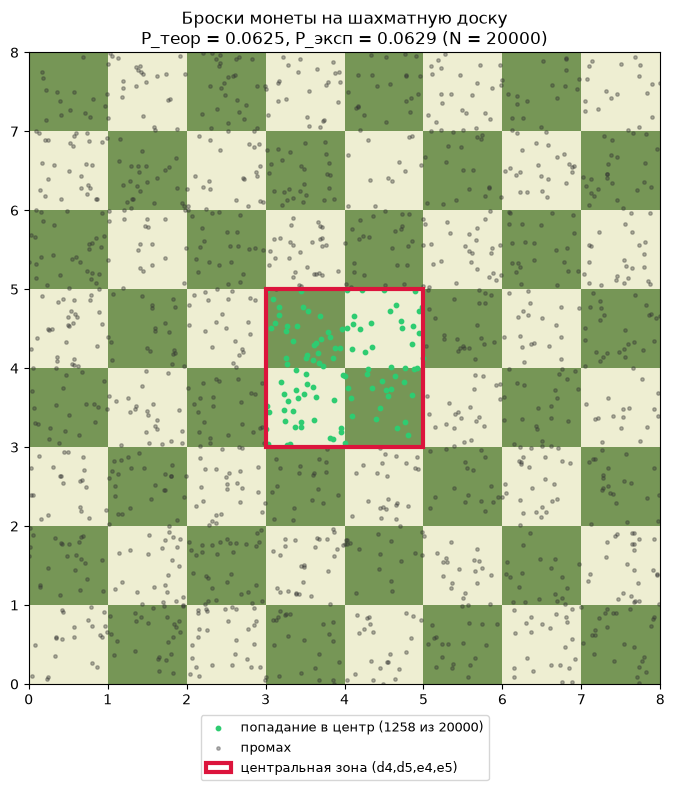

In [4]:
fig, ax = plt.subplots(figsize=(8, 8))

n_cells = int(L)
for i in range(n_cells):
    for j in range(n_cells):
        color = "#EEEED2" if (i + j) % 2 == 0 else "#769656"
        ax.add_patch(patches.Rectangle((i, j), 1, 1, facecolor=color, edgecolor="none", zorder=0))

show_n = 1500
idx = np.random.choice(N, size=min(show_n, N), replace=False)
ax.scatter(xs[idx][hits[idx]], ys[idx][hits[idx]], s=10, color="#2ecc71",
           label=f"попадание в центр ({hits.sum()} из {N})", zorder=2)
ax.scatter(xs[idx][~hits[idx]], ys[idx][~hits[idx]], s=6, color="#333333", alpha=0.35,
           label="промах", zorder=2)

ax.add_patch(patches.Rectangle((center_low, center_low), a, a, fill=False,
                                edgecolor="crimson", linewidth=3, zorder=3,
                                label="центральная зона (d4,d5,e4,e5)"))

ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_aspect("equal")
ax.set_xticks(range(n_cells + 1))
ax.set_yticks(range(n_cells + 1))
ax.set_title(f"Броски монеты на шахматную доску\n"
             f"P_теор = {P_theory:.4f}, P_эксп = {P_empirical:.4f} (N = {N})")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.04), ncol=1, fontsize=9)
plt.tight_layout()
plt.show()

## 4. Сходимость эмпирической вероятности к теоретической

Покажем, как экспериментальная оценка $P$ приближается к теоретическому значению по мере роста числа бросков $N$ (иллюстрация закона больших чисел).

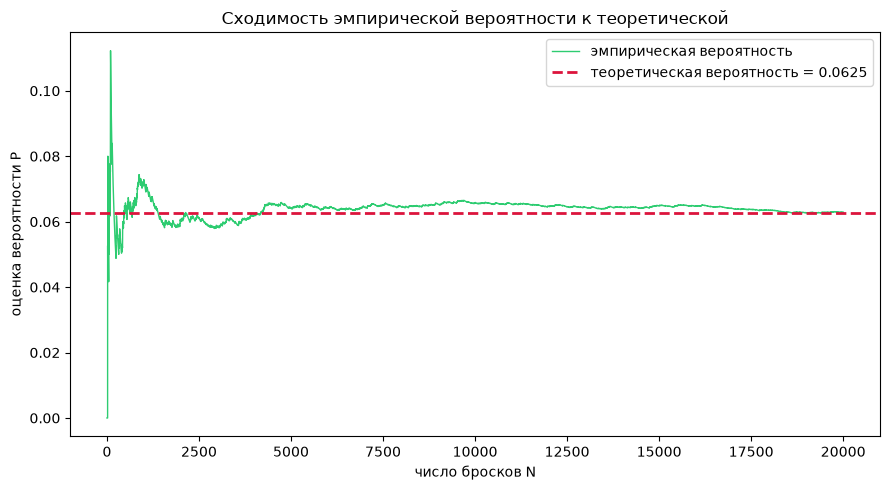

In [5]:
cumulative_hits = np.cumsum(hits)
trial_numbers = np.arange(1, N + 1)
running_P = cumulative_hits / trial_numbers

plt.figure(figsize=(9, 5))
plt.plot(trial_numbers, running_P, color="#2ecc71", linewidth=1, label="эмпирическая вероятность")
plt.axhline(P_theory, color="crimson", linestyle="--", linewidth=2,
            label=f"теоретическая вероятность = {P_theory:.4f}")
plt.xlabel("число бросков N")
plt.ylabel("оценка вероятности P")
plt.title("Сходимость эмпирической вероятности к теоретической")
plt.legend()
plt.tight_layout()
plt.show()